#1. LOAD THE DATA

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv('Housing.csv')

In [18]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [19]:
df.shape

(1460, 81)

In [20]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

In [21]:
print(df["SalePrice"].describe())

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


# 2. EDA

In [22]:
missing = df.isnull().sum()
missing = missing[missing>0].sort_values(ascending=False)

print("length of missing values :", {len(missing)})
print(missing)

length of missing values : {19}
PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


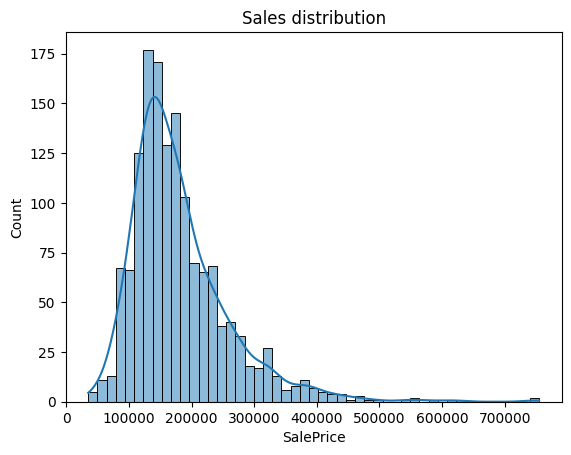

In [23]:
sns.histplot(df['SalePrice'],kde=True)
plt.title('Sales distribution')
plt.show()

In [24]:
numeric_cols = df.select_dtypes(include=np.number)
correlation = numeric_cols.corr()["SalePrice"].sort_values(ascending=False)
print(correlation)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
GarageYrBlt      0.486362
MasVnrArea       0.477493
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.351799
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

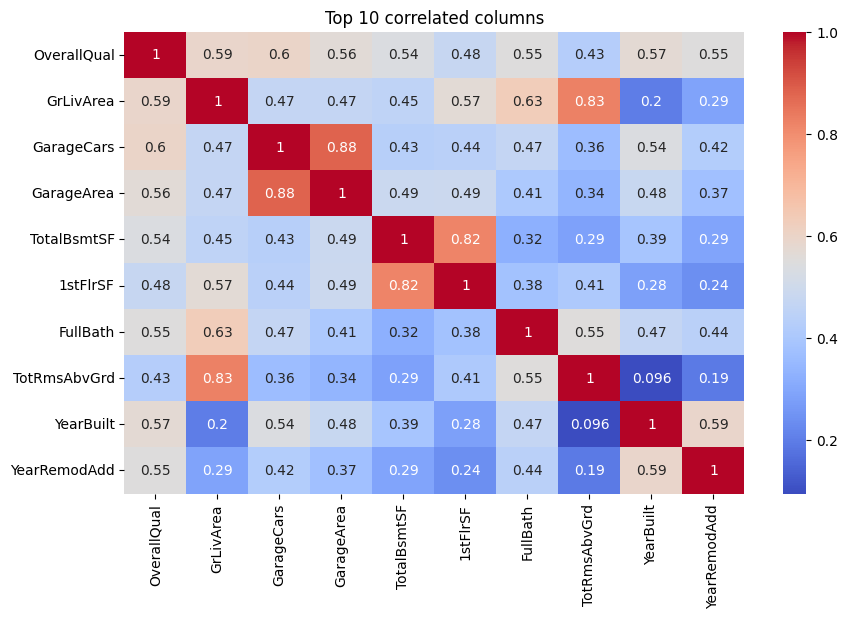

In [25]:
top_cols = correlation[1:11].index

plt.figure(figsize = (10,6))
sns.heatmap(df[top_cols].corr() , annot = True , cmap="coolwarm")
plt.title("Top 10 correlated columns")
plt.show()

#3. PREPROCESSING

In [26]:
cols_to_drop = ["PoolQC" , "MiscFeature" , "Alley","Fence",
                "MasVnrType","FireplaceQu","Id"]
df.drop(cols_to_drop,axis=1,inplace=True,errors='ignore')

print("remaning columns:" ,df.shape[1])

remaning columns: 74


In [27]:
df.shape

(1460, 74)

In [28]:
#Fill missing numerical values

nums_cols = df.select_dtypes(include=np.number).columns
df[nums_cols] = df[nums_cols].fillna(df[nums_cols].median())

print("Missing in numeric cols: ",df[nums_cols].isnull().sum().sum())

Missing in numeric cols:  0


In [29]:
#Fills missing Categorial Values

cat_col = df.select_dtypes(include="object").columns
df[cat_col] = df[cat_col].fillna(df[cat_col].mode().iloc[0])

#.iloc[0] -> give row at index position 0
#.mode() -> return most frequent value per column
print("Missing in Categorial cols: ",df[cat_col].isnull().sum().sum())

Missing in Categorial cols:  0


In [30]:
print("Total Missing Values remaining :" , df.isnull().sum().sum())

#.sum().sum() -> for total of all cols missing value
#.sum() -> missing values of each col

Total Missing Values remaining : 0


In [31]:
#Encode categorial Values

df =pd.get_dummies(df,drop_first=True)
print("Shape after encoding :",df.shape)

#get_dummies() -> convert all text cols to numbers
#drop_first -> avoids reduntant cols

Shape after encoding : (1460, 230)


# 4. Training

In [32]:
x = df.drop("SalePrice",axis=1)
y=df["SalePrice"]

print("Feature shape :",x.shape)
print("Target shappe :",y.shape)

Feature shape : (1460, 229)
Target shappe : (1460,)


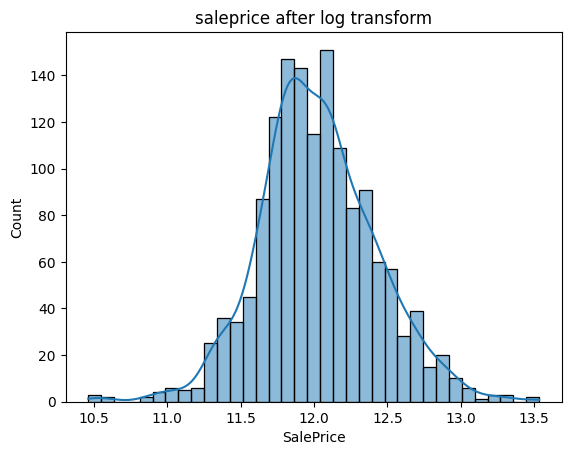

In [33]:
#Log Transformation

y = np.log1p(y)

sns.histplot(y,kde=True)
plt.title("saleprice after log transform")
plt.show()

In [34]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

print("Train size :",x_train.shape)
print("Test size :",x_test.shape)

Train size : (1168, 229)
Test size : (292, 229)


In [35]:
#Train linear Regression

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score

lr = LinearRegression()
lr.fit(x_train,y_train)
print("Training Score :",lr.score(x_train,y_train))

Training Score : 0.9435767180933696


In [36]:
#Train random Forest Regressor

from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
print("Training Score :",rf.score(x_train,y_train))

Training Score : 0.9811086012039315


# 5. Model evalution

In [37]:
from sklearn.metrics import mean_squared_error

#predications
lr_pred = lr.predict(x_test)
rf_pred = rf.predict(x_test)

#RMSE(Root Mean squared Error)
lr_rmse = np.sqrt(mean_squared_error(y_test,lr_pred))
rf_rmse = np.sqrt(mean_squared_error(y_test,rf_pred))

print(f"Linear Regression RMSE: {lr_rmse}")
print(f"Random Forest RMSE: {rf_rmse}")

Linear Regression RMSE: 0.20809504739872364
Random Forest RMSE: 0.14685599307530312


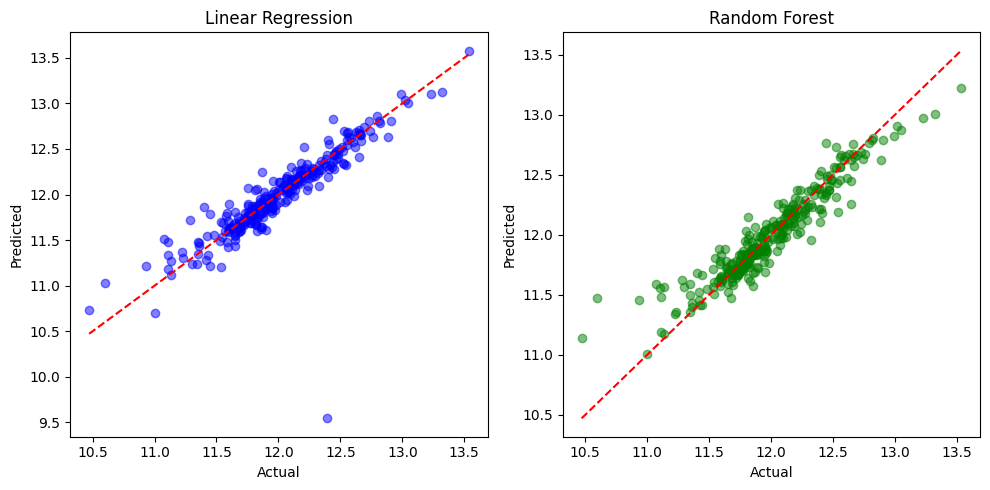

In [38]:
plt.figure(figsize=(10, 5))

# Linear Regression
plt.subplot(1, 2, 1)
plt.scatter(y_test, lr_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("Linear Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")

# Random Forest
plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_pred, alpha=0.5, color="green")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.tight_layout()
plt.show()

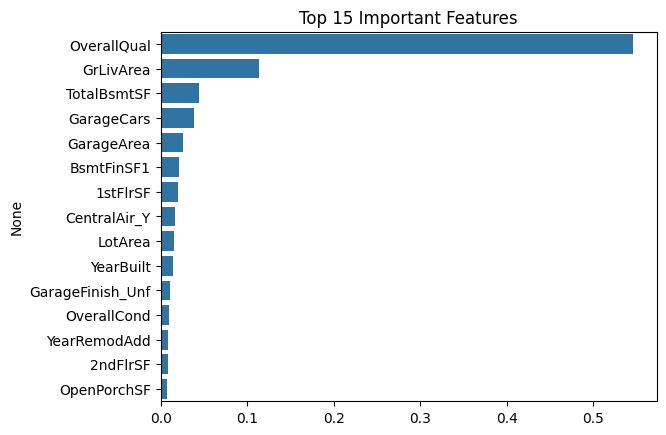

In [39]:
feat_imp = pd.Series(rf.feature_importances_,
                     index=x.columns).sort_values(ascending=False)[:15]

sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Top 15 Important Features")
plt.show()

# 6.Prdict House Prices

In [40]:
# Pick a few houses from test set
sample = x_test.iloc[:5]
actual = y_test.iloc[:5]

# Predict (still in log scale)
rf_pred_log = rf.predict(sample)

# Reverse log transform to get actual dollars
rf_pred_actual = np.expm1(rf_pred_log)
actual_prices  = np.expm1(actual)

# Compare
results = pd.DataFrame({
    "Actual Price ($)"   : actual_prices.values.astype(int),
    "Predicted Price ($)": rf_pred_actual.astype(int),
    "Difference ($)"     : (actual_prices.values - rf_pred_actual).astype(int)
})

print(results)

   Actual Price ($)  Predicted Price ($)  Difference ($)
0            154500               141839           12660
1            324999               317066            7933
2            114999               116395           -1395
3            158999               152816            6183
4            315500               319118           -3618


In [41]:
# Create a house with same columns as training data
custom_house = pd.DataFrame([x_train.iloc[0]])  # copy structure

# Modify key features
custom_house["OverallQual"]  = 8    # high quality
custom_house["GrLivArea"]    = 2000 # 2000 sqft living area
custom_house["GarageCars"]   = 2    # 2 car garage
custom_house["TotalBsmtSF"]  = 1000 # basement size
custom_house["YearBuilt"]    = 2005 # fairly new

# Predict
log_price = rf.predict(custom_house)
price = np.expm1(log_price)
print(f"Predicted House Price: ${price[0]:,.0f}")

Predicted House Price: $241,610


# 7. Improve the Model

In [42]:
# Feature Engineering

# Create new features before splitting X and y
df["TotalSF"]      = df["TotalBsmtSF"] + df["1stFlrSF"] + df["2ndFlrSF"]  # total house size
df["HouseAge"]     = df["YrSold"] - df["YearBuilt"]                        # how old when sold
df["Remodeled"]    = (df["YearRemodAdd"] != df["YearBuilt"]).astype(int)   # was it remodeled?
df["TotalBath"]    = df["FullBath"] + (df["HalfBath"] * 0.5)               # total bathrooms
df["GarageScore"]  = df["GarageCars"] * df["GarageArea"]                   # garage quality score

print("New columns added:", ["TotalSF", "HouseAge", "Remodeled", "TotalBath", "GarageScore"])

New columns added: ['TotalSF', 'HouseAge', 'Remodeled', 'TotalBath', 'GarageScore']


In [43]:
!pip install xgboost -q

In [44]:
# XGBoost

from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    verbosity=0
)

xgb.fit(x_train, y_train)
xgb_pred = xgb.predict(x_test)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

print(f"Linear Regression RMSE: 0.2081")
print(f"Random Forest RMSE:     0.1473")
print(f"XGBoost RMSE:           {xgb_rmse:.4f}")

Linear Regression RMSE: 0.2081
Random Forest RMSE:     0.1473
XGBoost RMSE:           0.1350
